# Finite Size Scaling — Modelo de Ising 2D

Análisis de escalado de tamaño finito (FSS) para el modelo de Ising 2D simulado con tres algoritmos: **Metropolis**, **Glauber** y **Wolff**.

Se determinan:
- La temperatura crítica $T_c$ mediante el cruce del cumulante de Binder $U_4$.
- Los exponentes críticos $\nu$, $\beta/\nu$ y $\gamma/\nu$ mediante ajustes log-log.
- El colapso de datos como verificación del escalado.

## 1. Importaciones y carga de datos

Leemos los ficheros de simulación. Cada uno tiene columnas: `L, T, e, m, Cv, m2, m4`.
A partir de ellas calculamos el cumulante de Binder $U_4 = 1 - \frac{\langle m^4\rangle}{3\langle m^2\rangle^2}$ y la susceptibilidad $\chi = L^2(\langle m^2\rangle - \langle |m|\rangle^2)$.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import brentq, curve_fit

# Parametros para que todas las graficas salgan iguales
plt.rcParams.update({
    'figure.figsize': (8, 5),
    'font.size': 12,
    'lines.linewidth': 1.5,
    'lines.markersize': 4,
})

# Ficheros de datos, sus nombres
archivos = {
    'Metropolis': 'metropolis_2d.txt',
    'Glauber':    'glauber_2d.txt',
    'Wolff':      'wolff_2d.txt',
}

columnas = ['L', 'T', 'e', 'm', 'Cv', 'm2', 'm4']

# Leer y añadir columnas derivadas
data = {}
for algo, fichero in archivos.items():
    df = pd.read_csv(fichero, sep=r'\s+', header=None, names=columnas)
    df['U4']  = 1.0 - df['m4'] / (3.0 * df['m2']**2)
    df['chi'] = df['L']**2 * (df['m2'] - df['m']**2)
    data[algo] = df

L_values = sorted(data['Wolff']['L'].unique())
print('Tamaños de red:', L_values)

Tamaños de red: [16, 32, 64, 128]


## 2. Funciones auxiliares

- **`find_Tc`**: Encuentra $T_c$ como el promedio de los cruces de $U_4(T)$ entre pares consecutivos de $L$.
- **`get_exponents`**: Calcula los exponentes críticos a partir de ajustes lineales en escala log-log:
  - $1/\nu$: pendiente de $\ln|dU_4/dT|$ vs $\ln L$
  - $\beta/\nu$: pendiente (cambiada de signo) de $\ln\langle|m|\rangle(T_c)$ vs $\ln L$
  - $\gamma/\nu$: pendiente de $\ln\chi_{\max}$ vs $\ln L$

In [5]:
def linfit(x, a, b):
    """Recta y = a*x + b para ajustar en escala log-log."""
    return a * x + b


def find_Tc(df, L_values):
    """Calcula Tc como media de los cruces de U4 entre pares consecutivos de L."""
    # Interpolar U4(T) para cada L
    interps = {}
    for L in L_values:
        s = df[df['L'] == L].sort_values('T')
        interps[L] = interp1d(s['T'].values, s['U4'].values, kind='linear')

    # Buscar el cruce entre cada par (L_i, L_{i+1})
    crossings = []
    for L1, L2 in zip(L_values[:-1], L_values[1:]):
        s1 = df[df['L'] == L1]
        s2 = df[df['L'] == L2]
        T_min = max(s1['T'].min(), s2['T'].min(), 1.8)
        T_max = min(s1['T'].max(), s2['T'].max(), 2.8)

        Ts = np.linspace(T_min, T_max, 1000)
        diff = interps[L1](Ts) - interps[L2](Ts)

        for j in range(len(diff) - 1):
            if diff[j] * diff[j + 1] < 0:
                Tc = brentq(lambda t: interps[L1](t) - interps[L2](t),
                            Ts[j], Ts[j + 1])
                crossings.append(Tc)
                break

    return np.mean(crossings), np.std(crossings)


def get_exponents(df, L_values, Tc):
    """Calcula nu, beta/nu y gamma/nu mediante ajustes log-log."""
    interp_U4 = {}
    interp_m = {}
    for L in L_values:
        s = df[df['L'] == L].sort_values('T')
        interp_U4[L] = interp1d(s['T'].values, s['U4'].values, kind='cubic')
        interp_m[L]  = interp1d(s['T'].values, s['m'].values,  kind='cubic')

    dT = 0.001

    # 1/nu: derivada de U4 en Tc
    log_L, log_dU = [], []
    for L in L_values:
        s = df[df['L'] == L]
        if Tc - dT >= s['T'].min() and Tc + dT <= s['T'].max():
            deriv = abs((interp_U4[L](Tc + dT) - interp_U4[L](Tc - dT)) / (2 * dT))
            log_L.append(np.log(L))
            log_dU.append(np.log(deriv))
    (inv_nu, _), _ = curve_fit(linfit, log_L, log_dU)
    nu = 1.0 / inv_nu

    # beta/nu: magnetización en Tc
    log_L, log_m = [], []
    for L in L_values:
        s = df[df['L'] == L]
        if s['T'].min() <= Tc <= s['T'].max():
            log_L.append(np.log(L))
            log_m.append(np.log(interp_m[L](Tc)))
    (slope_m, _), _ = curve_fit(linfit, log_L, log_m)
    beta_over_nu = -slope_m

    # gamma/nu: máximo de chi
    log_L, log_chi = [], []
    for L in L_values:
        s = df[df['L'] == L]
        log_L.append(np.log(L))
        log_chi.append(np.log(s['chi'].max()))
    (gamma_over_nu, _), _ = curve_fit(linfit, log_L, log_chi)

    return nu, beta_over_nu, gamma_over_nu

## 3. Cálculo de $T_c$ y exponentes críticos

Para cada algoritmo obtenemos $T_c$, $\nu$, $\beta$ y $\gamma$. También comprobamos la relación de hiperescalado $\gamma/\nu + 2\beta/\nu = d = 2$.

In [6]:
rows = []
for algo, df in data.items():
    Tc, Tc_err = find_Tc(df, L_values)
    nu, bn, gn = get_exponents(df, L_values, Tc)
    rows.append({
        'algoritmo': algo, 'Tc': Tc, 'Tc_err': Tc_err,
        'nu': nu, 'beta_over_nu': bn, 'gamma_over_nu': gn,
        'beta': bn * nu, 'gamma': gn * nu,
    })

results = pd.DataFrame(rows).set_index('algoritmo')
results['hiperescalado'] = results['gamma_over_nu'] + 2 * results['beta_over_nu']
results

,Tc,Tc_err,nu,beta_over_nu,gamma_over_nu,beta,gamma,hiperescalado
algoritmo,,,,,,,,
Metropolis,2.263075,0.004003,0.498665,0.115086,1.820706,0.057389,0.907923,2.050878
Glauber,2.248328,0.017093,5.731985,0.042976,1.894057,0.246338,10.856708,1.980009
Wolff,2.273961,0.002267,0.985465,0.133179,1.763787,0.131243,1.738150,2.030144


## 4. Observables vs temperatura

Representamos $\langle|m|\rangle$, $\chi$, $C_v$ y $U_4$ en función de $T$, superpuestos para los tres algoritmos y todos los tamaños $L$.

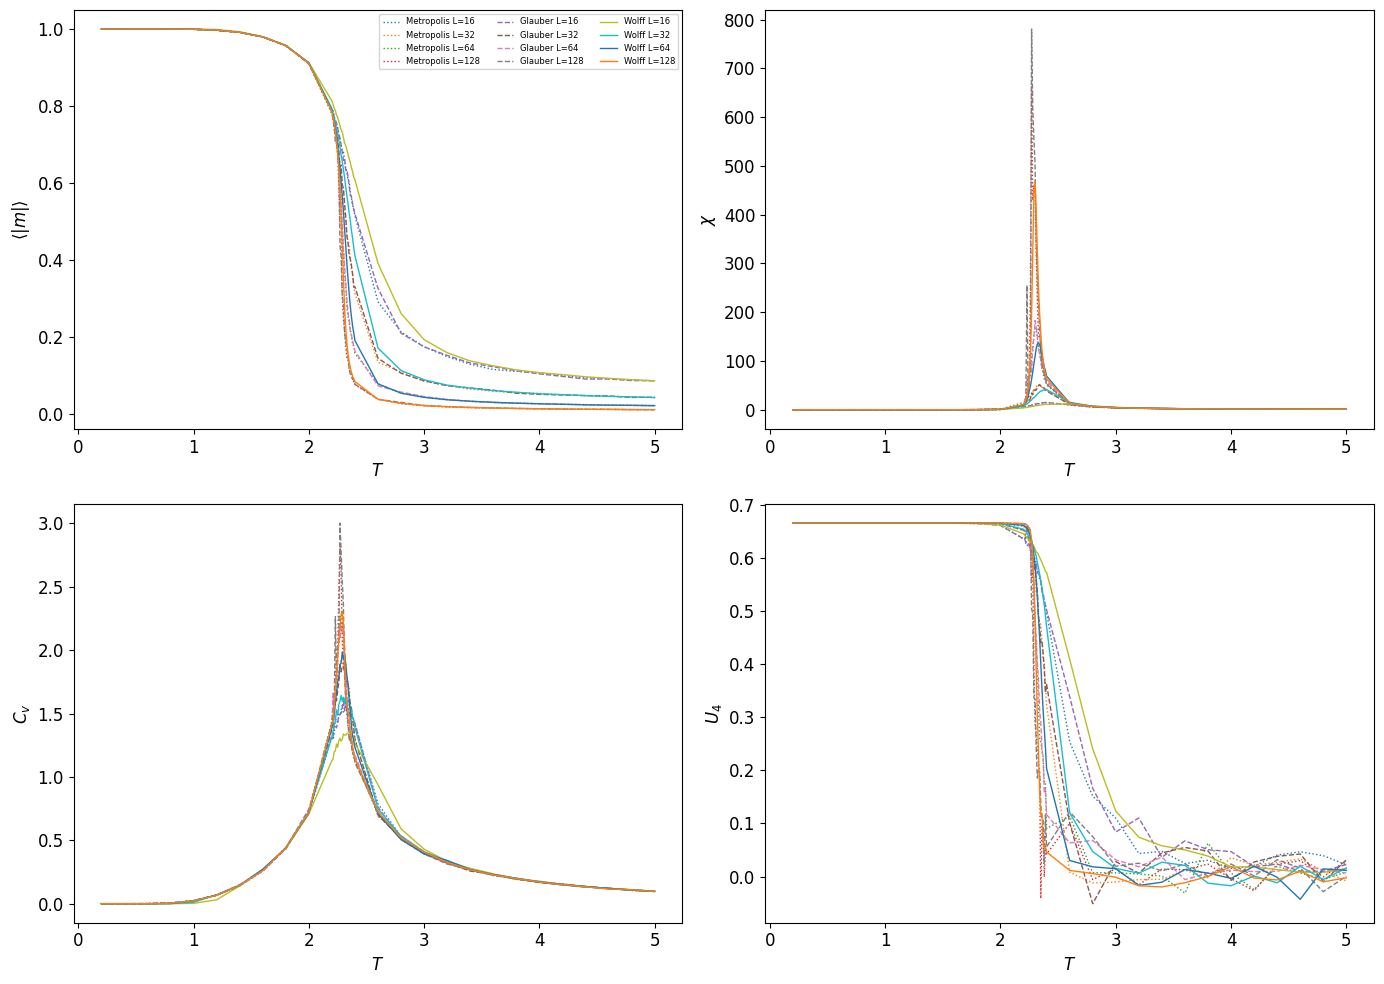

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
observables = [
    ('m',   r'$\langle |m| \rangle$'),
    ('chi', r'$\chi$'),
    ('Cv',  r'$C_v$'),
    ('U4',  r'$U_4$'),
]
estilos = {'Wolff': '-', 'Glauber': '--', 'Metropolis': ':'}

for ax, (col, ylabel) in zip(axes.flat, observables):
    for algo, df in data.items():
        for L in L_values:
            s = df[df['L'] == L].sort_values('T')
            label = f'{algo} L={L}' if col == 'm' else None
            ax.plot(s['T'], s[col], estilos[algo], ms=2, lw=1, label=label)
    ax.set_xlabel(r'$T$')
    ax.set_ylabel(ylabel)

axes[0, 0].legend(fontsize=6, ncol=3)
plt.tight_layout()
plt.show()

## 5. Cumulante de Binder $U_4$

Un panel por algoritmo mostrando $U_4(T)$ para cada $L$, con la línea vertical en $T_c$. El cruce de las curvas para distintos $L$ señala la temperatura crítica.

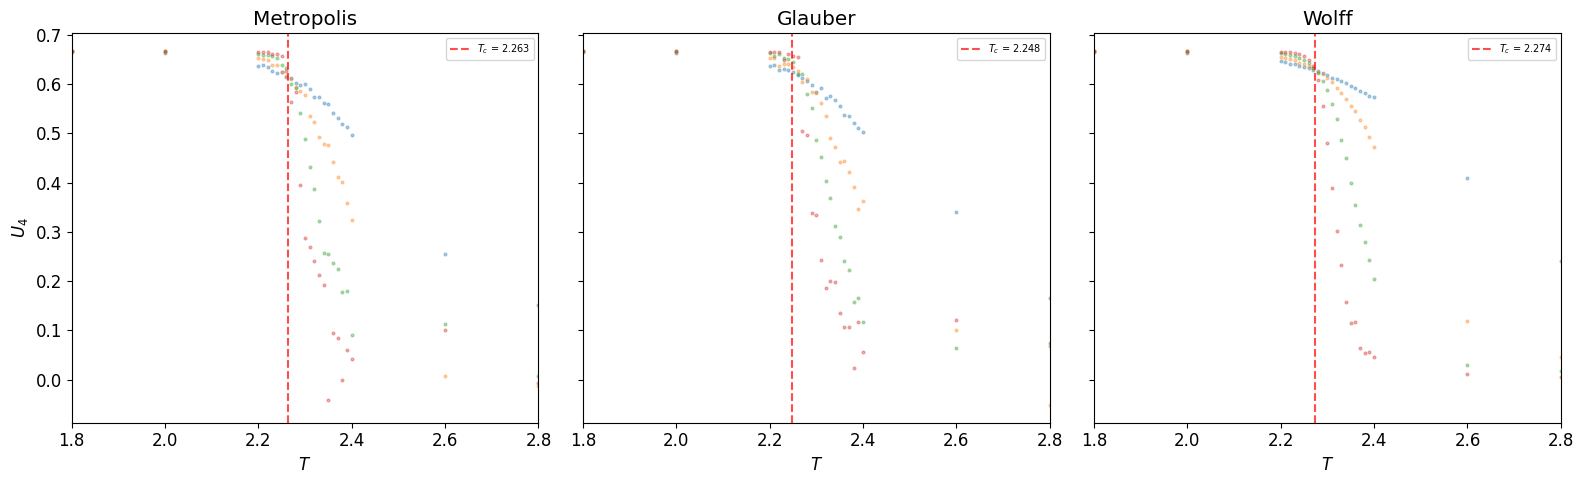

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (algo, df) in zip(axes, data.items()):
    Tc = results.loc[algo, 'Tc']
    for L in L_values:
        s = df[df['L'] == L].sort_values('T').copy()
        ax.plot(s['T'], s['U4'],        'o', ms=2, alpha=0.35)
    ax.axvline(Tc, color='red', ls='--', alpha=0.7, label=f'$T_c$ = {Tc:.3f}')
    ax.set_xlim(1.8, 2.8)
    ax.set_xlabel(r'$T$')
    ax.set_title(algo)
    ax.legend(fontsize=7)

axes[0].set_ylabel(r'$U_4$')
plt.tight_layout()
plt.show()